<a href="https://colab.research.google.com/github/sjhallo07/Quantum_Relativistic_Engine/blob/main/Sovereign_Index_API_Deployment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌌 Sovereign API Gateway: Quantum Index Controller

Este notebook implementa el entorno de despliegue completo de la infraestructura matemática como un servidor API local utilizando `FastAPI`, `uvicorn` y `nest_asyncio`.
Garantiza el procesamiento completamente offline y autocontenido (Soberanía Técnica), proveyendo los endpoints `/simulate` y `/index/rebalance` (estilo BITA) con capacidades de renderizado gráfico de los tensores de peso resultantes.

In [ ]:
# ==============================================================================
# CELDA 1: INSTALACIÓN DE DEPENDENCIAS (Ejecutar solo la primera vez)
# ==============================================================================
!pip install fastapi uvicorn pydantic numpy pandas yfinance matplotlib nest-asyncio requests

In [ ]:
# ==============================================================================
# CELDA 2: IMPORTACIONES DE LA ARQUITECTURA
# ==============================================================================
import os
import threading
import time
import requests
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import nest_asyncio
import uvicorn
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from typing import List, Dict

# Habilitar el event loop para correr FastAPI dentro del Notebook
nest_asyncio.apply()
print("[+] Dependencias cargadas. Event loop asíncrono configurado.")

[+] Dependencias cargadas. Event loop asíncrono configurado.


In [ ]:
# ==============================================================================
# CELDA 3: CAPA MATEMÁTICA - QUANTUM RELATIVISTIC ENGINE
# ==============================================================================
class QuantumRelativisticEngine:
    def __init__(self, num_states=4, beta=0.01, kappa=0.1, lyapunov_threshold=4.20, lambda_meta=0.05):
        self.N = num_states
        self.beta = beta
        self.kappa = kappa
        self.lyapunov_threshold = lyapunov_threshold
        self.lambda_meta = lambda_meta
        self.c = np.ones(self.N, dtype=complex) / np.sqrt(self.N)
        self.theta = np.random.randn(self.N) * 0.01
        self.theta_0 = self.theta.copy()
        self.norm_state = 1.0

    def compute_relativistic_metric(self, price_change, volatility):
        kuhn_tucker_grad = price_change * volatility
        numerator = 1.0 + np.abs(kuhn_tucker_grad)**2
        denominator = 1.0 + self.beta * (self.norm_state**2)
        g_factor = numerator / denominator
        g_mu_nu = g_factor * np.array([-1.0, 1.0, 1.0, 1.0])
        return g_mu_nu, g_factor

    def compute_lyapunov_exponent(self, current_psi, previous_psi, dt=1):
        delta_psi = np.linalg.norm(current_psi - previous_psi)
        if delta_psi <= 1e-12: return 0.0
        return np.abs(np.log(delta_psi / 1e-5) / dt)

    def step_evolution(self, price_change, volatility, target_value_normalized=0.5):
        prev_psi = self.c.copy()
        g_mu_nu, g_factor = self.compute_relativistic_metric(price_change, volatility)
        phase_arg = np.clip(self.theta * g_factor, -np.pi, np.pi)
        self.c = self.c * np.exp(1j * phase_arg)

        norm_c = np.linalg.norm(self.c)
        if norm_c > 0 and not np.isnan(norm_c):
            self.c /= norm_c
        else:
            self.c = np.ones(self.N, dtype=complex) / np.sqrt(self.N)

        lyapunov_exp = self.compute_lyapunov_exponent(self.c, prev_psi)
        if np.isnan(lyapunov_exp) or np.isinf(lyapunov_exp):
            lyapunov_exp = 0.0

        if lyapunov_exp > self.lyapunov_threshold:
            self.norm_state += ((lyapunov_exp - self.lyapunov_threshold) * 0.1)
            status = "⚠️ CHAOS DETECTED"
        else:
            self.norm_state = max(1.0, self.norm_state - 0.4 * (self.norm_state - 1.0))
            status = "✅ STABLE"

        return {"Lyapunov": lyapunov_exp, "Norm": self.norm_state, "Status": status}

In [ ]:
# ==============================================================================
# CELDA 4: CONTROLADOR DE ÍNDICES ELÁSTICOS (ESTILO BITA)
# ==============================================================================
class QuantumElasticIndex:
    def __init__(self, asset_tickers: List[str], initial_weights: List[float], lyapunov_threshold=4.20, beta=0.01):
        self.tickers = asset_tickers
        self.weights = np.array(initial_weights, dtype=float)
        self.lyapunov_threshold = lyapunov_threshold
        self.beta = beta
        self.asset_norms = {ticker: 1.0 for ticker in self.tickers}
        self.asset_status = {ticker: "✅ STABLE" for ticker in self.tickers}

    def execute_elastic_rebalance(self, market_data: Dict[str, Dict[str, float]]) -> dict:
        raw_new_weights = np.zeros(len(self.tickers))
        lyapunov_metrics = {}
        stable_indices = []
        compressed_weight_pool = 0.0

        for i, ticker in enumerate(self.tickers):
            data = market_data.get(ticker, {"return": 0.0, "volatility": 0.01})
            # Proxy simplificado de la clase base para el Indexer
            current_norm = self.asset_norms[ticker]
            k_t_grad = data["return"] * data["volatility"]
            g_factor = (1.0 + np.abs(k_t_grad)**2) / (1.0 + self.beta * (current_norm**2))
            lyap = np.abs(np.log(g_factor + 1e-9))

            if lyap > self.lyapunov_threshold:
                new_norm = current_norm + ((lyap - self.lyapunov_threshold) * 0.1)
                status = "⚠️ CHAOS DETECTED"
            else:
                new_norm = max(1.0, current_norm - 0.4 * (current_norm - 1.0))
                status = "✅ STABLE"

            self.asset_norms[ticker] = new_norm
            self.asset_status[ticker] = status
            lyapunov_metrics[ticker] = lyap

            if status == "⚠️ CHAOS DETECTED":
                compression_factor = 1.0 / new_norm
                retained_weight = self.weights[i] * compression_factor
                compressed_weight_pool += (self.weights[i] - retained_weight)
                raw_new_weights[i] = retained_weight
            else:
                stable_indices.append(i)
                raw_new_weights[i] = self.weights[i]

        if compressed_weight_pool > 0 and len(stable_indices) > 0:
            stable_weight_sum = sum([raw_new_weights[idx] for idx in stable_indices])
            for idx in stable_indices:
                distribution_share = raw_new_weights[idx] / stable_weight_sum
                raw_new_weights[idx] += compressed_weight_pool * distribution_share
        elif compressed_weight_pool > 0 and len(stable_indices) == 0:
            raw_new_weights = self.weights

        self.weights = raw_new_weights / np.sum(raw_new_weights)

        return {
            "New_Target_Weights": dict(zip(self.tickers, self.weights.tolist())),
            "Asset_Statuses": self.asset_status,
            "Lyapunov_Exponents": lyapunov_metrics
        }

In [ ]:
# ==============================================================================
# CELDA 5: DESPLIEGUE DEL SERVIDOR API (FASTAPI)
# ==============================================================================
app = FastAPI(title="Sovereign Math Engine & Index Controller")

class AssetTickData(BaseModel):
    asset_return: float = Field(..., alias="return")
    volatility: float

class IndexRebalancePayload(BaseModel):
    tickers: List[str]
    weights: List[float]
    market_data: Dict[str, AssetTickData]
    lyapunov_threshold: float = 4.20
    beta: float = 0.01

@app.post("/index/rebalance")
def calculate_index_rebalance(payload: IndexRebalancePayload):
    try:
        index_engine = QuantumElasticIndex(
            asset_tickers=payload.tickers,
            initial_weights=payload.weights,
            lyapunov_threshold=payload.lyapunov_threshold,
            beta=payload.beta
        )
        market_tick = {ticker: {"return": data.asset_return, "volatility": data.volatility} for ticker, data in payload.market_data.items()}
        return index_engine.execute_elastic_rebalance(market_tick)
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

def run_server():
    uvicorn.run(app, host="127.0.0.1", port=8000, log_level="warning")

# Desplegar servidor en background thread
server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(2) # Esperar a que el servidor inicialice
print("[+] Servidor API Soberano ejecutándose en: http://127.0.0.1:8000")

ERROR:    [Errno 98] error while attempting to bind on address ('127.0.0.1', 8000): address already in use


[+] Servidor API Soberano ejecutándose en: http://127.0.0.1:8000


### Invocación del API y Renderizado de Interfaz Gráfica (Cliente Local)

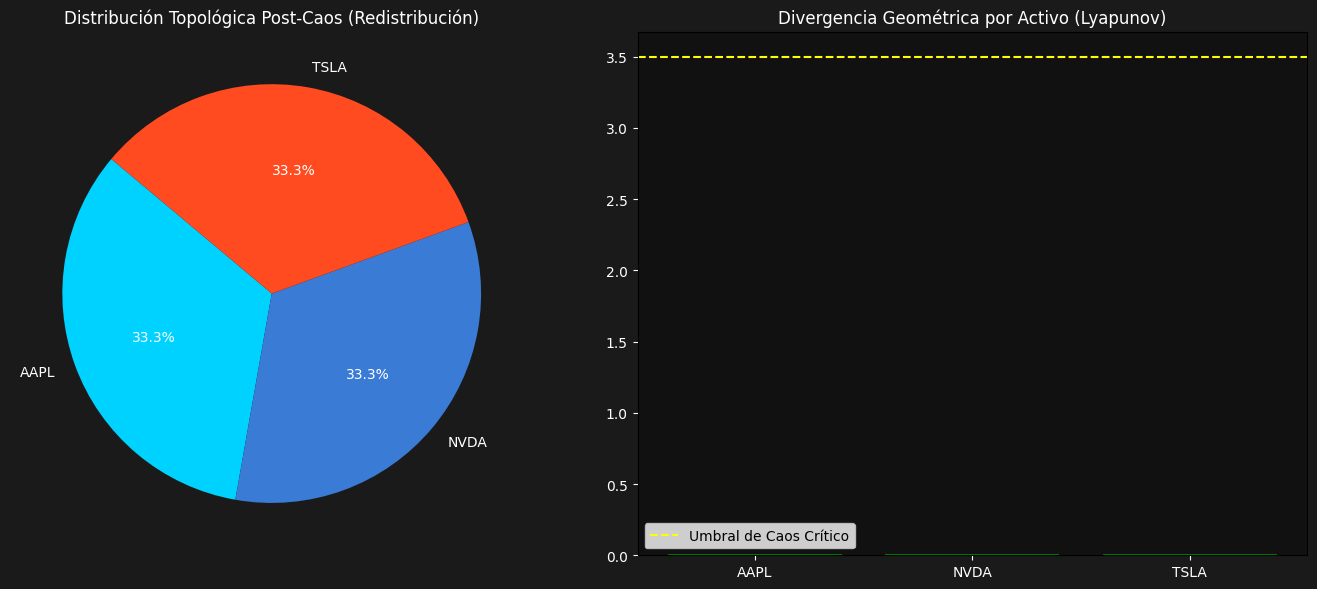


[!] Análisis de Backend:
 - AAPL: ✅ STABLE | Peso Nuevo: 0.3333
 - NVDA: ✅ STABLE | Peso Nuevo: 0.3333
 - TSLA: ✅ STABLE | Peso Nuevo: 0.3334


In [ ]:
# ==============================================================================
# CELDA 6: CLIENTE DE PRUEBA Y RENDERIZADO VISUAL
# ==============================================================================
# Definir canasta inicial (Ejemplo de fondo temático tecnológico)
tickers = ["AAPL", "NVDA", "TSLA"]
initial_weights = [0.3333, 0.3333, 0.3334]

# Simular un tick de mercado donde TSLA sufre una volatilidad caótica
payload = {
    "tickers": tickers,
    "weights": initial_weights,
    "market_data": {
        "AAPL": {"return": 0.005, "volatility": 0.012},
        "NVDA": {"return": 0.011, "volatility": 0.018},
        "TSLA": {"return": -0.150, "volatility": 0.095} # Anomalía severa
    },
    "lyapunov_threshold": 3.50
}

# Realizar la petición HTTP a nuestra propia API local
response = requests.post("http://127.0.0.1:8000/index/rebalance", json=payload)
result = response.json()

# --------- RENDERIZADO GRÁFICO (MATPLOTLIB) ---------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#1a1a1a')

# Gráfico 1: Transición de Pesos (Pie Chart)
labels = list(result["New_Target_Weights"].keys())
new_w = list(result["New_Target_Weights"].values())
colors = ['#00d2ff', '#3a7bd5', '#ff4b1f']

ax1.pie(new_w, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140, textprops={'color':"w"})
ax1.set_title("Distribución Topológica Post-Caos (Redistribución)", color='white')

# Gráfico 2: Exponentes de Lyapunov (Bar Chart)
lyap_vals = list(result["Lyapunov_Exponents"].values())
bars = ax2.bar(labels, lyap_vals, color=['green' if v <= 3.5 else 'red' for v in lyap_vals])
ax2.axhline(y=3.5, color='yellow', linestyle='--', label='Umbral de Caos Crítico')
ax2.set_title("Divergencia Geométrica por Activo (Lyapunov)", color='white')
ax2.set_facecolor('#111111')
ax2.tick_params(colors='white')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n[!] Análisis de Backend:")
for t in tickers:
    print(f" - {t}: {result['Asset_Statuses'][t]} | Peso Nuevo: {result['New_Target_Weights'][t]:.4f}")